In [2]:

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import os, cv2, numpy as np


In [3]:
def jpeg_compress(img, quality=5):
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
    result, encimg = cv2.imencode('.jpg', img, encode_param)
    decimg = cv2.imdecode(encimg, 1)
    return decimg


In [4]:
class JPEGDataset(Dataset):

    def __init__(self, root_dir, img_size=224):
        self.paths = [os.path.join(root_dir,f) for f in os.listdir(root_dir)]

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((img_size,img_size))
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):

        img = cv2.imread(self.paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        corrupted = jpeg_compress(img, quality=5)

        clean = self.transform(img)
        corrupted = self.transform(corrupted)

        return corrupted, clean


In [5]:
DATA_PATH = r"D:\Image Recognition\data"

dataset = JPEGDataset(DATA_PATH)
loader = DataLoader(dataset, batch_size=8, shuffle=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)


Using: cuda


In [6]:
class Block(nn.Module):
    def __init__(self, a, b):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(a,b,3,1,1),
            nn.BatchNorm2d(b),
            nn.ReLU()
        )
    def forward(self,x): return self.net(x)

class ProcessingNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            Block(3,64), Block(64,64),
            nn.MaxPool2d(2),
            Block(64,128), Block(128,128),
            nn.Upsample(scale_factor=2),
            Block(128,64),
            nn.Conv2d(64,3,3,1,1),
            nn.Sigmoid()
        )
    def forward(self,x): return self.net(x)


In [7]:
model = ProcessingNet().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 10


In [8]:
for epoch in range(EPOCHS):

    epoch_loss = 0
    pbar = tqdm(loader)

    for corrupted, clean in pbar:

        corrupted, clean = corrupted.to(device), clean.to(device)

        output = model(corrupted)
        loss = criterion(output, clean)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        pbar.set_postfix(mse=loss.item())

    print(f"Epoch {epoch+1} Loss: {epoch_loss/len(loader):.6f}")


100%|██████████| 375/375 [02:13<00:00,  2.80it/s, mse=0.00455]


Epoch 1 Loss: 0.006957


100%|██████████| 375/375 [01:38<00:00,  3.82it/s, mse=0.00353]


Epoch 2 Loss: 0.005609


100%|██████████| 375/375 [01:37<00:00,  3.86it/s, mse=0.00308]


...

Epoch 8 Loss: 0.003364


100%|██████████| 375/375 [01:39<00:00,  3.75it/s, mse=0.00251]


Epoch 9 Loss: 0.003268


100%|██████████| 375/375 [01:36<00:00,  3.90it/s, mse=0.00299]

Epoch 10 Loss: 0.003274


In [9]:
torch.save(model.state_dict(),"JPEG_deblock_model.pth")
print("JPEG Deblocking model saved ")


JPEG Deblocking model saved 


Text(0.5, 1.0, 'Ground Truth')

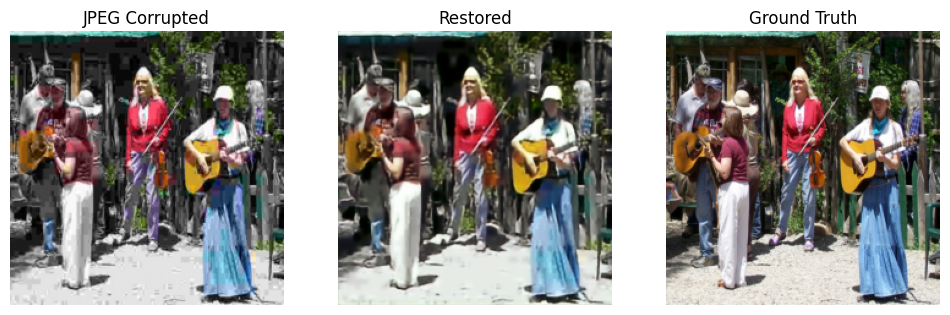

In [10]:
corrupted, clean = next(iter(loader))
corrupted = corrupted.to(device)

with torch.no_grad():
    restored = model(corrupted).cpu()

def show(img):
    img = img.permute(1,2,0).numpy()
    img = np.clip(img,0,1)
    plt.imshow(img); plt.axis("off")

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); show(corrupted[0].cpu()); plt.title("JPEG Corrupted")
plt.subplot(1,3,2); show(restored[0]); plt.title("Restored")
plt.subplot(1,3,3); show(clean[0]); plt.title("Ground Truth")


In [11]:
total_mse = 0

with torch.no_grad():
    for corrupted, clean in loader:
        corrupted, clean = corrupted.to(device), clean.to(device)
        restored = model(corrupted)
        total_mse += criterion(restored,clean).item()

print("Average MSE:", total_mse/len(loader))


Average MSE: 0.0034094854903717834


In [12]:
import math

def compute_metrics(model, loader):

    mse_total = 0
    psnr_total = 0

    with torch.no_grad():
        for corrupted, clean in loader:

            corrupted = corrupted.to(device)
            clean = clean.to(device)

            restored = model(corrupted)

            mse = ((restored-clean)**2).mean().item()
            mse_total += mse

            psnr = 10*math.log10(1/mse)
            psnr_total += psnr

    return mse_total/len(loader), psnr_total/len(loader)

mse, psnr = compute_metrics(model, loader)

print("Average MSE :", mse)
print("Average PSNR:", psnr, "dB")


Average MSE : 0.003380449425118665
Average PSNR: 24.85499535201673 dB
